# Week 3: Quantitative Model Comparison — Vicsek vs. Pull
**CSCI-5423 Final Project | CU Boulder**  
**Authors:** Asher (asal7747) & George (gest9386)  
**Models:** Vicsek (1995) alignment model vs. Pull model (Sayin et al. 2025)  
**Field reference:** Weinburd et al. (2024)

---
This notebook loads both Week 2 result JSONs and produces head-to-head figures across all four metrics. George's Pull model results will be loaded from his directory once finalized; a placeholder path is used until then.

## 0. Imports & paths

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy import stats

# ── Directory layout ──────────────────────────────────────────────────────────
BASE   = Path('/mnt/work_1/gest9386/CU_Boulder/CSCI-5423/Final_Project')

WEEK1        = BASE / 'week1'
WEEK2        = BASE / 'week2'
WEEK3        = BASE / 'week3'
FIGURES      = WEEK3 / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

VICSEK_JSON = WEEK2 / 'week2_results.json'
PULL_JSON   = WEEK2 / 'week2_pull_results.json'   # George creates this

print('Figures will be saved to:', FIGURES)
print('Vicsek JSON exists:', VICSEK_JSON.exists())
print('Pull   JSON exists:', PULL_JSON.exists())

Figures will be saved to: /mnt/work_1/gest9386/CU_Boulder/CSCI-5423/Final_Project/week3/figures
Vicsek JSON exists: True
Pull   JSON exists: True


## 1. Load results

In [2]:
with open(VICSEK_JSON) as f:
    vicsek_data = json.load(f)

# ── Pull model: load from George's file once available ────────────────────────
# Placeholder mirrors the Vicsek JSON schema so all downstream cells run now.
# Replace this block with `json.load(open(PULL_JSON))` when George's file lands.
PULL_READY = PULL_JSON.exists()
if PULL_READY:
    with open(PULL_JSON) as f:
        pull_data = json.load(f)
    print('Pull model results loaded from George\'s directory.')
else:
    print('WARNING: Pull JSON not found — using placeholder zeros. '
          'Replace once George finalizes week2_results.json.')
    pull_data = {
        'pull': {
            'n_agents': None,
            'eta_calibrated': None,
        },
        'metrics': {
            'polarization_mean': float('nan'),
            'polarization_std':  float('nan'),
            'turning_angle_std': float('nan'),
            'nnd_median':        float('nan'),
            'nnd_mean':          float('nan'),
        },
        'field_targets': vicsek_data['field_targets']   # shared ground truth
    }

# ── Convenience aliases ───────────────────────────────────────────────────────
vm  = vicsek_data['metrics']
pm  = pull_data['metrics']
ft  = vicsek_data['field_targets']     # field targets are identical in both JSONs
vp  = vicsek_data['vicsek']            # vicsek params
# pull params key may be 'pull' or 'params' — handle both
pp  = pull_data.get('pull', pull_data.get('params', {}))

print('\nVicsek metrics :', vm)
print('Pull   metrics :', pm)
print('Field  targets :', ft)

Pull model results loaded from George's directory.

Vicsek metrics : {'polarization_mean': 0.8235226751239662, 'polarization_std': 0.050660405819338436, 'turning_angle_std': 0.5947353404093519, 'nnd_median': 2.6055509063882134, 'nnd_mean': 3.0218240091135886}
Pull   metrics : {'polarization_mean': 0.05819803121559264, 'polarization_std': 0.030297549339450735, 'turning_angle_std': 1.9990629561407725, 'nnd_median': 1.3241716967281547, 'nnd_mean': 1.3395213297532285}
Field  targets : {'polarization_mean': 0.8196, 'polarization_std': 0.0615, 'turning_angle_std': 0.276, 'nnd_median': 3.893, 'nnd_mean': 4.473}


## 2. Shared plot style

In [3]:
# ── Palette ───────────────────────────────────────────────────────────────────
C_FIELD  = '#2c2c2c'   # near-black  — field data
C_VICSEK = '#e07b39'   # orange      — Vicsek
C_PULL   = '#4a90d9'   # blue        — Pull

plt.rcParams.update({
    'font.family':     'sans-serif',
    'font.size':       11,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.labelsize':  12,
    'axes.titlesize':  13,
    'figure.dpi':      150,
})

LABEL_FIELD  = 'Field (Weinburd 2024)'
LABEL_VICSEK = f'Vicsek  η={vp["eta_calibrated"]} rad'
LABEL_PULL   = f'Pull  η={pp.get("eta_calibrated", "?"):.2g} rad' if pp.get('eta_calibrated') else 'Pull model'

print('Labels:', LABEL_FIELD, '|', LABEL_VICSEK, '|', LABEL_PULL)

Labels: Field (Weinburd 2024) | Vicsek  η=1.3 rad | Pull  η=0.2 rad


## 3. Metric 1 — Polarization

Vicsek order parameter $\Phi = |\langle e^{i\theta} \rangle|$.  
Target: mean = 0.820, std = 0.062.

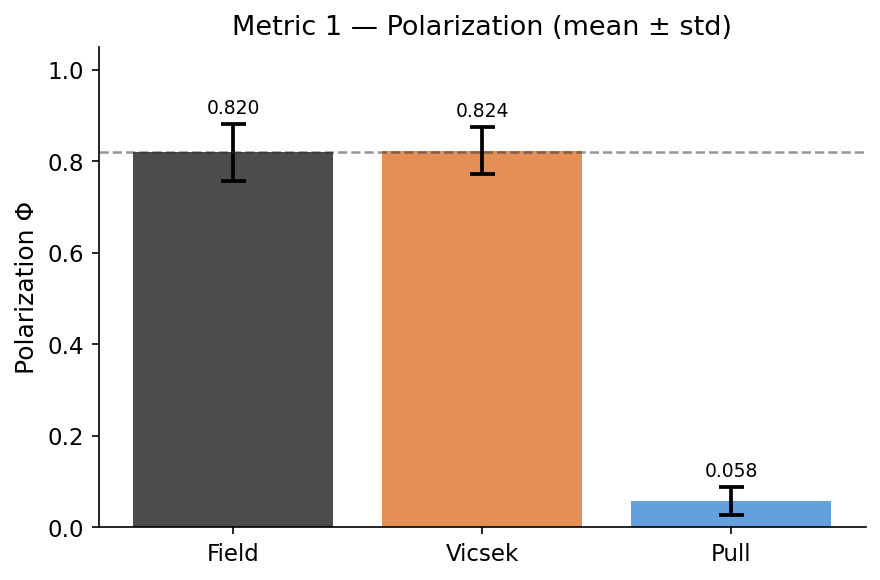

Saved: w3_metric1_polarization.png


In [4]:
fig, ax = plt.subplots(figsize=(6, 4))

models = ['Field', 'Vicsek', 'Pull']
means  = [ft['polarization_mean'], vm['polarization_mean'], pm['polarization_mean']]
stds   = [ft['polarization_std'],  vm['polarization_std'],  pm['polarization_std']]
colors = [C_FIELD, C_VICSEK, C_PULL]

x = np.arange(len(models))
bars = ax.bar(x, means, yerr=stds, capsize=6, color=colors, alpha=0.85,
               error_kw={'elinewidth': 1.8, 'ecolor': 'k', 'capthick': 1.8})

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Polarization Φ')
ax.set_ylim(0, 1.05)
ax.set_title('Metric 1 — Polarization (mean ± std)')
ax.axhline(ft['polarization_mean'], color=C_FIELD, lw=1.2, ls='--', alpha=0.5)

# Annotate values
for bar, m, s in zip(bars, means, stds):
    if not np.isnan(m):
        ax.text(bar.get_x() + bar.get_width()/2, m + s + 0.015,
                f'{m:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES / 'w3_metric1_polarization.png', dpi=150)
plt.show()
print('Saved: w3_metric1_polarization.png')

## 4. Metric 2 — Turning Angle Std

The **critical diagnostic**: Vicsek requires η = 1.3 rad (≈ 5× empirical) to match polarization.  
If Pull matches polarization at η ≈ 0.26 rad, that is the central mechanistic result.

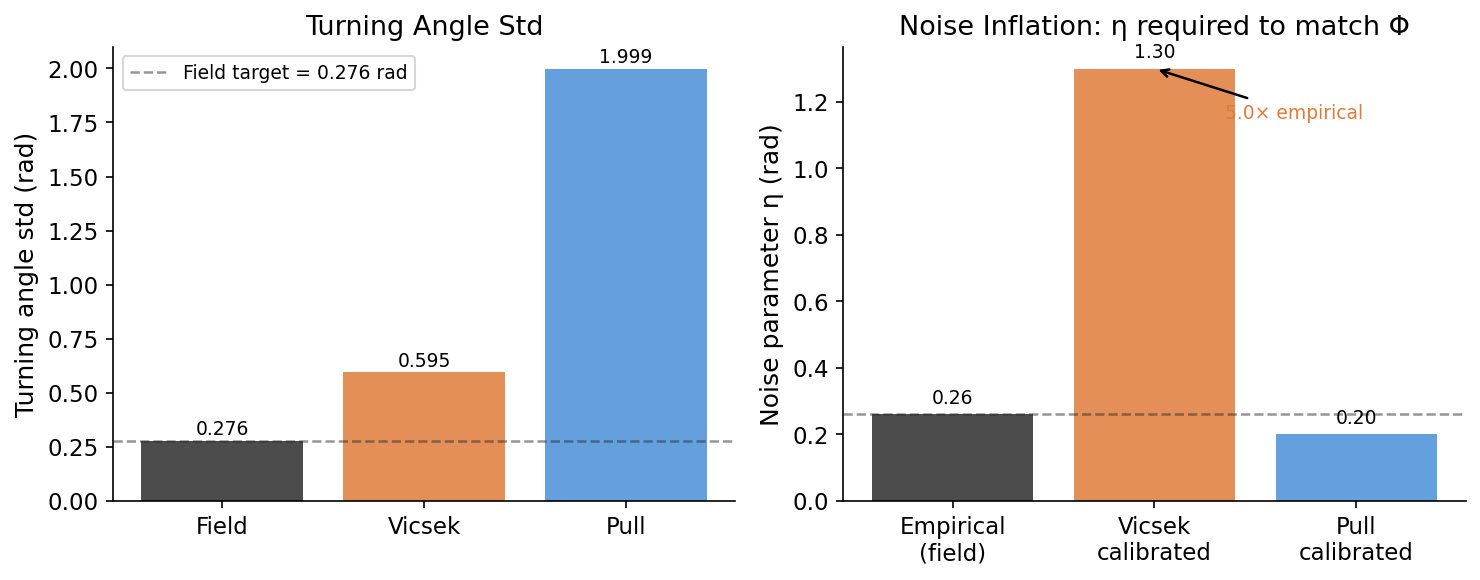

Saved: w3_metric2_turning_angles.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ── Left: scalar bar comparison ───────────────────────────────────────────────
ax = axes[0]
vals   = [ft['turning_angle_std'], vm['turning_angle_std'], pm['turning_angle_std']]
colors = [C_FIELD, C_VICSEK, C_PULL]
x = np.arange(3)
bars = ax.bar(x, vals, color=colors, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(['Field', 'Vicsek', 'Pull'])
ax.set_ylabel('Turning angle std (rad)')
ax.set_title('Turning Angle Std')
ax.axhline(ft['turning_angle_std'], color=C_FIELD, lw=1.2, ls='--', alpha=0.5,
           label=f'Field target = {ft["turning_angle_std"]:.3f} rad')
ax.legend(fontsize=9)
for bar, v in zip(bars, vals):
    if not np.isnan(v):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)

# ── Right: noise parameter vs turning angle outcome ───────────────────────────
# Shows the «noise inflation» required by Vicsek vs field empirical value
ax2 = axes[1]
eta_field   = vp['eta_empirical']            # 0.26 rad — empirical
eta_vicsek  = vp['eta_calibrated']           # 1.3 rad  — needed to hit polarization
eta_pull    = pp.get('eta_calibrated', np.nan)

labels  = ['Empirical\n(field)', 'Vicsek\ncalibrated', 'Pull\ncalibrated']
eta_vals = [eta_field, eta_vicsek, eta_pull]
bar_cols = [C_FIELD, C_VICSEK, C_PULL]

bars2 = ax2.bar(np.arange(3), eta_vals, color=bar_cols, alpha=0.85)
ax2.set_xticks(np.arange(3))
ax2.set_xticklabels(labels)
ax2.set_ylabel('Noise parameter η (rad)')
ax2.set_title('Noise Inflation: η required to match Φ')
ax2.axhline(eta_field, color=C_FIELD, lw=1.2, ls='--', alpha=0.5)

# Annotate the 5× inflation for Vicsek
if not np.isnan(eta_vicsek):
    ratio = eta_vicsek / eta_field
    ax2.annotate(f'{ratio:.1f}× empirical',
                 xy=(1, eta_vicsek), xytext=(1.35, eta_vicsek - 0.15),
                 arrowprops=dict(arrowstyle='->', color='k', lw=1.2),
                 fontsize=9, color=C_VICSEK)

for bar, v in zip(bars2, eta_vals):
    if not np.isnan(v):
        ax2.text(bar.get_x() + bar.get_width()/2, v + 0.02,
                 f'{v:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES / 'w3_metric2_turning_angles.png', dpi=150)
plt.show()
print('Saved: w3_metric2_turning_angles.png')

## 5. Metric 3 — Neighbor Density Map

Body-centered, focal heading points up.  
Field shows a forward void (exclusion zone ahead of focal locust).  
Vicsek produces an isotropic map — the forward void is absent.  
**This cell loads pre-computed density maps from each Week 2 notebook's figures directory,
or re-generates them if the raw simulation arrays are available.**

field    map PNG exists: True  (/mnt/work_1/gest9386/CU_Boulder/CSCI-5423/Final_Project/week1/figures/metric3_neighbor_density.png)
vicsek   map PNG exists: True  (/mnt/work_1/gest9386/CU_Boulder/CSCI-5423/Final_Project/week2/figures/vicsek_metric_3.png)
pull     map PNG exists: True  (/mnt/work_1/gest9386/CU_Boulder/CSCI-5423/Final_Project/week2/figures/pull_metric_3.png)


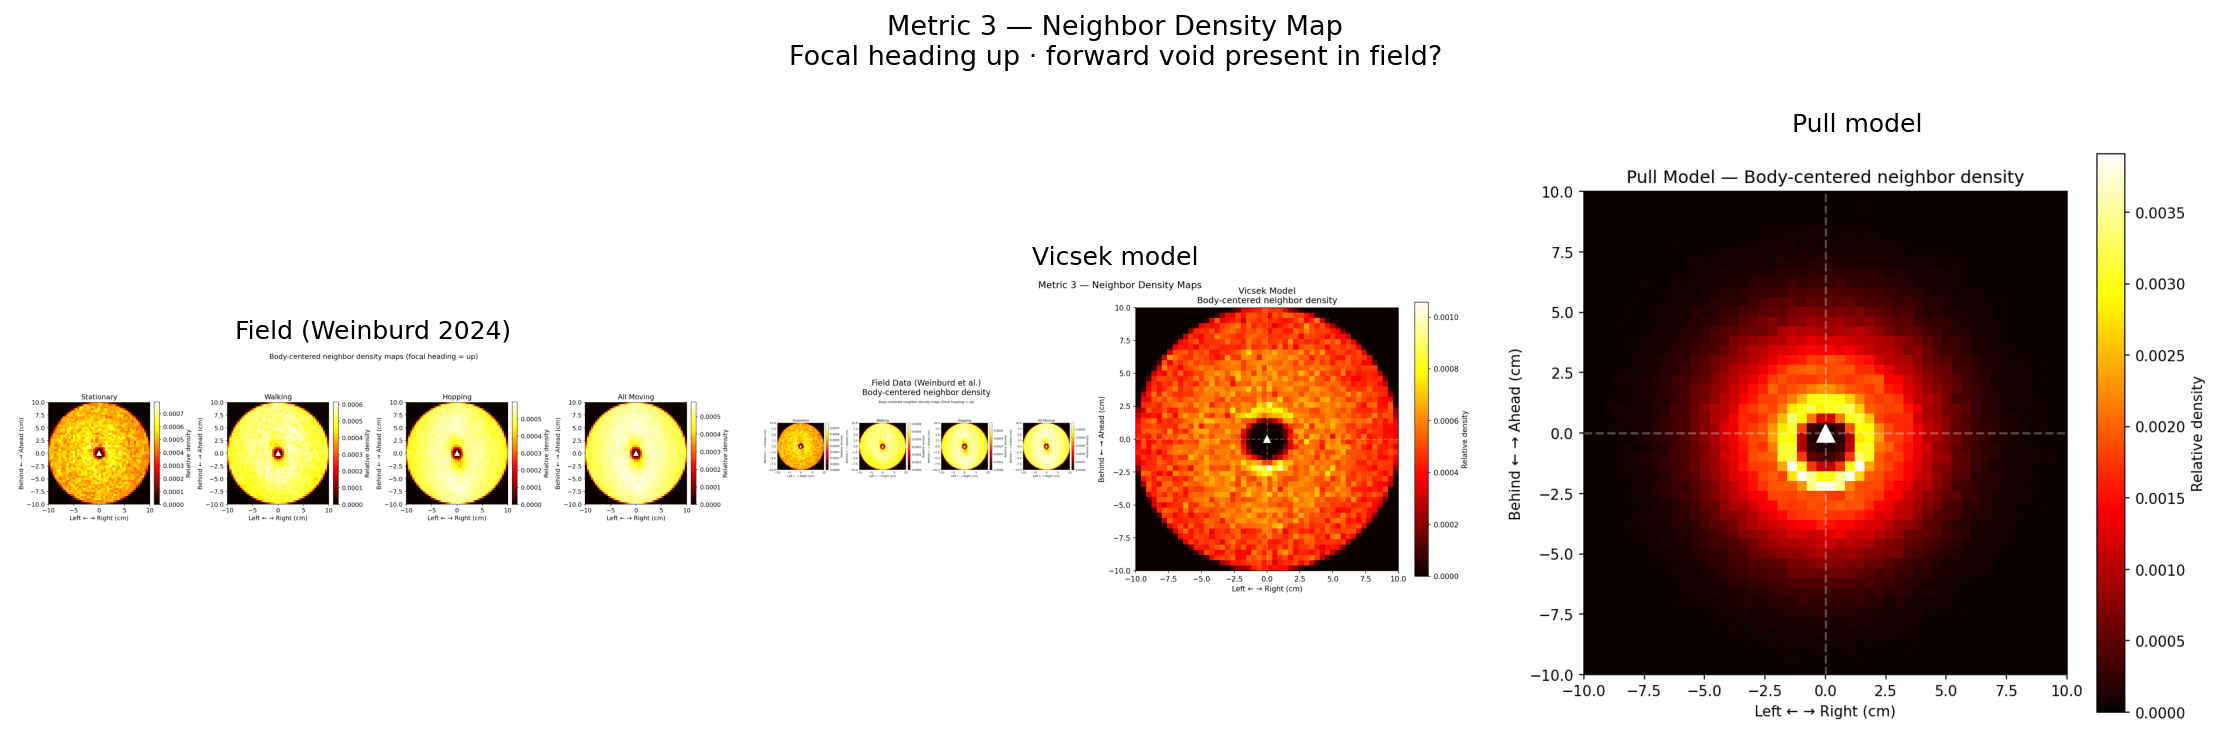

Saved: w3_metric3_neighbor_density.png


In [6]:
# ── Option A: display saved PNG side-by-side ──────────────────────────────────
# Adjust filenames to match what each Week 2 notebook actually saved.

FIG_FIELD_MAP  = WEEK1 / 'figures' / 'metric3_neighbor_density.png'
FIG_VICSEK_MAP = WEEK2 / 'figures' / 'vicsek_metric_3.png'
FIG_PULL_MAP   = WEEK2 / 'figures' / 'pull_metric_3.png'   # George creates this

available = {}
for label, path in [('field', FIG_FIELD_MAP),
                    ('vicsek', FIG_VICSEK_MAP),
                    ('pull',   FIG_PULL_MAP)]:
    available[label] = path.exists()
    print(f'{label:8s} map PNG exists: {path.exists()}  ({path})')

if all(available.values()):
    from matplotlib.image import imread
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    titles = ['Field (Weinburd 2024)', 'Vicsek model', 'Pull model']
    paths  = [FIG_FIELD_MAP, FIG_VICSEK_MAP, FIG_PULL_MAP]
    for ax, title, p in zip(axes, titles, paths):
        img = imread(str(p))
        ax.imshow(img)
        ax.set_title(title, fontsize=12)
        ax.axis('off')
    plt.suptitle('Metric 3 — Neighbor Density Map\n'
                 'Focal heading up · forward void present in field?',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    fig.savefig(FIGURES / 'w3_metric3_neighbor_density.png', dpi=150,
                bbox_inches='tight')
    plt.show()
    print('Saved: w3_metric3_neighbor_density.png')
else:
    print('\nOne or more map PNGs not yet available. '
          'Re-run once George\'s Week 2 notebook is finalized.')
    print('Alternatively, load raw simulation arrays here and call '
          'compute_neighbor_density_map() directly.')

### 5b. Anisotropy quantification (scalar summary for stats table)

If raw density arrays are available, compute a scalar anisotropy index:
$A = \frac{\rho_{\text{rear}} - \rho_{\text{front}}}{\rho_{\text{rear}} + \rho_{\text{front}}}$

where front/rear are defined as the anterior/posterior half of a body-radius annulus  
(see `compute_neighbor_density_map` in George's Week 1 notebook for coordinate conventions).

In [7]:
def anisotropy_index(density_map):
    """
    Scalar forward-void anisotropy index.
    density_map : 2-D array, shape (nbins, nbins)
                  origin at center, y-axis points in focal heading direction (up).
    Returns A in [-1, 1]; positive → more density behind than ahead (void ahead).
    """
    H, W = density_map.shape
    cy, cx = H // 2, W // 2
    front = density_map[:cy, :]   # y < 0  → ahead of focal (heading up)
    rear  = density_map[cy:, :]   # y > 0  → behind focal
    rho_f = front.mean()
    rho_r = rear.mean()
    denom = rho_f + rho_r
    return (rho_r - rho_f) / denom if denom > 0 else 0.0

# ── Placeholder — replace with actual arrays once available ───────────────────
# Example usage (uncomment and adapt):
# density_vicsek = np.load(WEEK2_ASHER / 'week2' / 'vicsek_density_map.npy')
# density_pull   = np.load(WEEK2_GEORGE / 'week2' / 'pull_density_map.npy')
# density_field  = np.load(BASE_GEORGE / 'week1' / 'field_density_map.npy')
# A_field, A_vicsek, A_pull = [anisotropy_index(d)
#                               for d in [density_field, density_vicsek, density_pull]]
# print(f'Anisotropy index — Field: {A_field:.3f} | Vicsek: {A_vicsek:.3f} | Pull: {A_pull:.3f}')

print('Anisotropy index function defined. Uncomment lines above once .npy arrays are saved.')

Anisotropy index function defined. Uncomment lines above once .npy arrays are saved.


## 6. Metric 4 — Nearest-Neighbor Distance (NND)

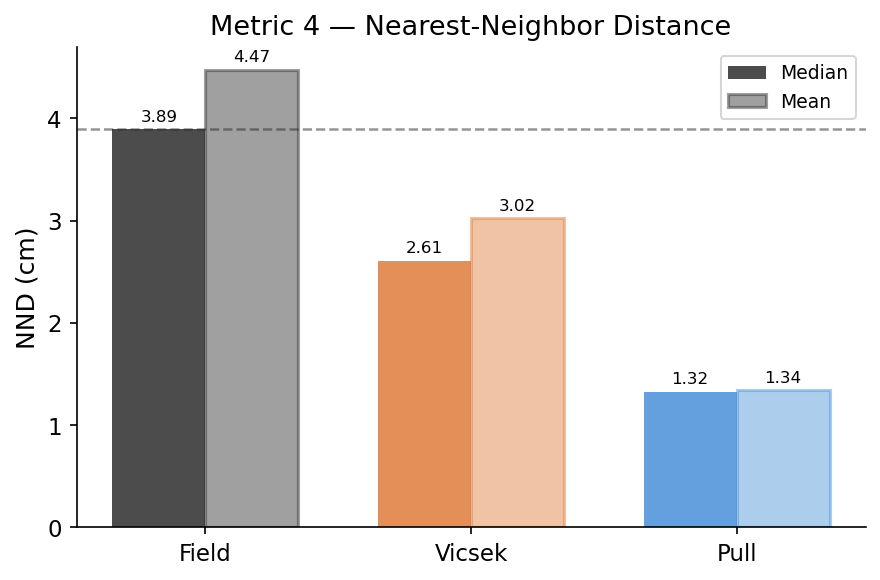

Saved: w3_metric4_nnd.png


In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

models  = ['Field', 'Vicsek', 'Pull']
medians = [ft['nnd_median'], vm['nnd_median'], pm['nnd_median']]
means   = [ft['nnd_mean'],   vm['nnd_mean'],   pm['nnd_mean']]
colors  = [C_FIELD, C_VICSEK, C_PULL]

x = np.arange(3)
width = 0.35

bars1 = ax.bar(x - width/2, medians, width, label='Median', color=colors, alpha=0.85)
bars2 = ax.bar(x + width/2, means,   width, label='Mean',   color=colors, alpha=0.45,
               edgecolor=colors, linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('NND (cm)')
ax.set_title('Metric 4 — Nearest-Neighbor Distance')
ax.legend(fontsize=9)
ax.axhline(ft['nnd_median'], color=C_FIELD, lw=1.2, ls='--', alpha=0.5)

for bars, vals in [(bars1, medians), (bars2, means)]:
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.05,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
fig.savefig(FIGURES / 'w3_metric4_nnd.png', dpi=150)
plt.show()
print('Saved: w3_metric4_nnd.png')

## 7. Summary figure — all four metrics on one canvas

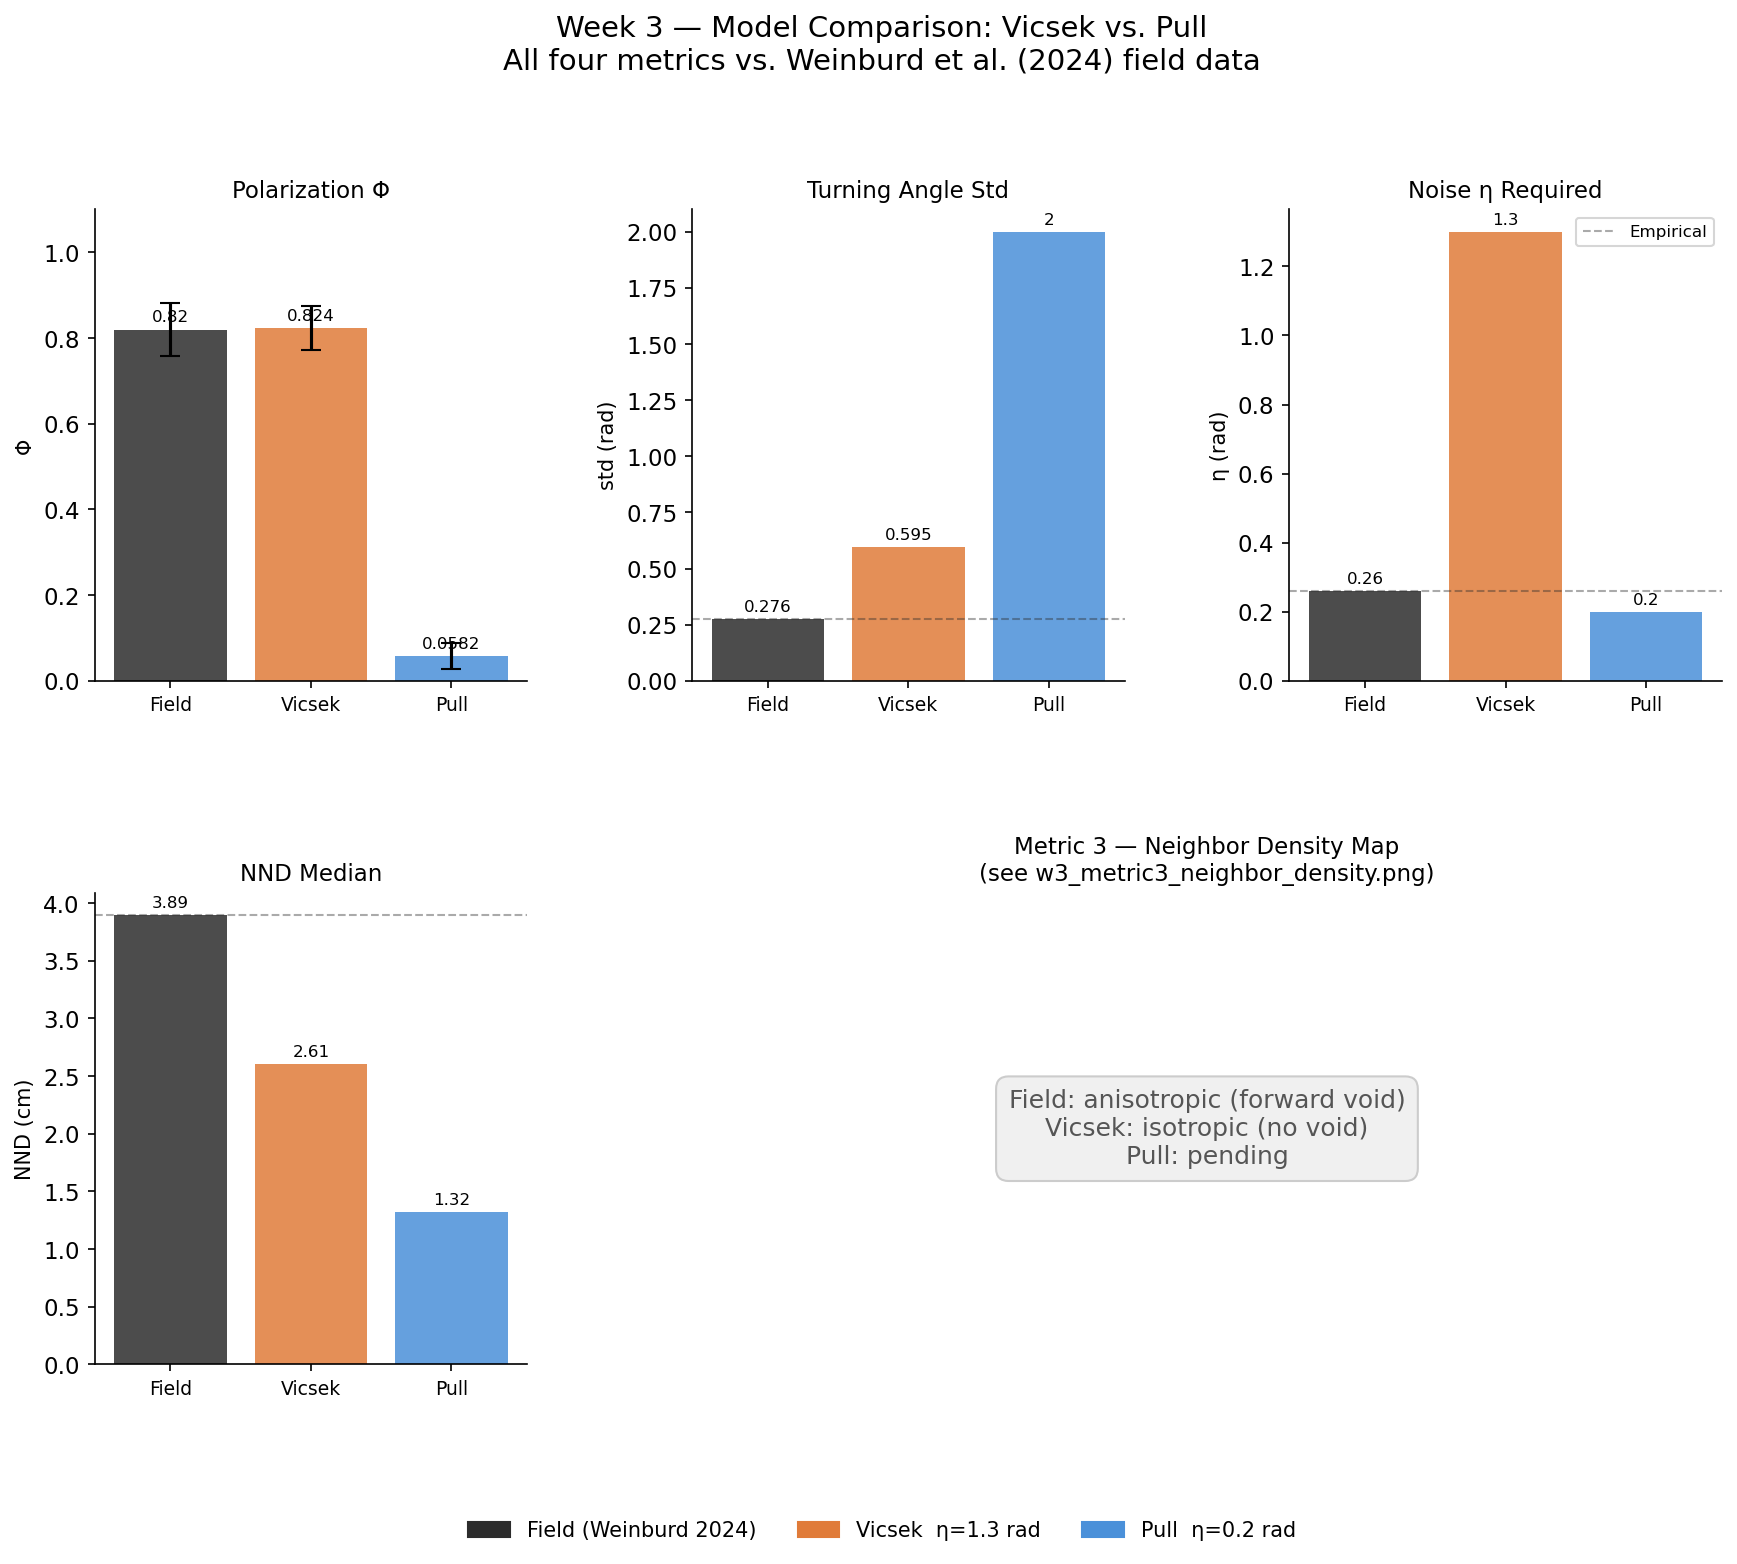

Saved: w3_summary_all_metrics.png


In [9]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

ax_pol   = fig.add_subplot(gs[0, 0])   # polarization
ax_turn  = fig.add_subplot(gs[0, 1])   # turning angle std
ax_noise = fig.add_subplot(gs[0, 2])   # noise parameter comparison
ax_nnd   = fig.add_subplot(gs[1, 0])   # NND
ax_aniso = fig.add_subplot(gs[1, 1:])  # anisotropy / neighbor map placeholder

def _bar3(ax, vals, title, ylabel, colors=(C_FIELD, C_VICSEK, C_PULL), ylim=None):
    x = np.arange(3)
    bars = ax.bar(x, vals, color=colors, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(['Field', 'Vicsek', 'Pull'], fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    if ylim: ax.set_ylim(ylim)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2,
                    v + ax.get_ylim()[1]*0.01,
                    f'{v:.3g}', ha='center', va='bottom', fontsize=8)

# Polarization
_bar3(ax_pol,
      [ft['polarization_mean'], vm['polarization_mean'], pm['polarization_mean']],
      'Polarization Φ', 'Φ', ylim=(0, 1.1))
ax_pol.errorbar([0,1,2],
                [ft['polarization_mean'], vm['polarization_mean'], pm['polarization_mean']],
                yerr=[ft['polarization_std'], vm['polarization_std'], pm['polarization_std']],
                fmt='none', ecolor='k', capsize=5, elinewidth=1.5)

# Turning angle std
_bar3(ax_turn,
      [ft['turning_angle_std'], vm['turning_angle_std'], pm['turning_angle_std']],
      'Turning Angle Std', 'std (rad)')
ax_turn.axhline(ft['turning_angle_std'], color=C_FIELD, lw=1, ls='--', alpha=0.4)

# Noise parameter
eta_pull_val = pp.get('eta_calibrated', np.nan)
_bar3(ax_noise,
      [vp['eta_empirical'], vp['eta_calibrated'], eta_pull_val],
      'Noise η Required', 'η (rad)')
ax_noise.axhline(vp['eta_empirical'], color=C_FIELD, lw=1, ls='--', alpha=0.4,
                 label='Empirical')
ax_noise.legend(fontsize=8)

# NND
_bar3(ax_nnd,
      [ft['nnd_median'], vm['nnd_median'], pm['nnd_median']],
      'NND Median', 'NND (cm)')
ax_nnd.axhline(ft['nnd_median'], color=C_FIELD, lw=1, ls='--', alpha=0.4)

# Neighbor map placeholder
ax_aniso.set_title('Metric 3 — Neighbor Density Map\n(see w3_metric3_neighbor_density.png)', fontsize=11)
ax_aniso.text(0.5, 0.5,
              'Field: anisotropic (forward void)\nVicsek: isotropic (no void)\nPull: pending',
              ha='center', va='center', transform=ax_aniso.transAxes,
              fontsize=12, color='#555',
              bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f0f0', edgecolor='#ccc'))
ax_aniso.axis('off')

# Legend
from matplotlib.patches import Patch
handles = [Patch(color=C_FIELD,  label=LABEL_FIELD),
           Patch(color=C_VICSEK, label=LABEL_VICSEK),
           Patch(color=C_PULL,   label=LABEL_PULL)]
fig.legend(handles=handles, loc='lower center', ncol=3,
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Week 3 — Model Comparison: Vicsek vs. Pull\n'
             'All four metrics vs. Weinburd et al. (2024) field data',
             fontsize=14, y=1.01)

fig.savefig(FIGURES / 'w3_summary_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: w3_summary_all_metrics.png')

## 8. Statistical tests

Each model is compared to its field target using a one-sample z-test on the scalar metrics  
(mean ± std from the JSON). Results are collected into a summary table.

In [10]:
def z_test_one_sample(observed_mean, target_mean, observed_std, n=2000):
    """
    One-sample z-test: H0 = observed_mean equals target_mean.
    n : number of simulation time-steps used to estimate the mean.
    Returns (z_stat, p_value).
    """
    se = observed_std / np.sqrt(n)
    if se == 0:
        return np.nan, np.nan
    z = (observed_mean - target_mean) / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p

n_steps = vicsek_data['vicsek']['n_steps']   # 2000

# ── Build results table ───────────────────────────────────────────────────────
rows = []

# Polarization — both models have mean + std
for model_label, m in [('Vicsek', vm), ('Pull', pm)]:
    z, p = z_test_one_sample(
        m['polarization_mean'], ft['polarization_mean'],
        m['polarization_std'], n=n_steps)
    rows.append({'model': model_label, 'metric': 'Polarization (mean)',
                 'observed': m['polarization_mean'], 'target': ft['polarization_mean'],
                 'delta': m['polarization_mean'] - ft['polarization_mean'],
                 'z': z, 'p': p})

# Turning angle std — scalar, no distribution std in JSON;
# use a simple relative error instead
for model_label, m in [('Vicsek', vm), ('Pull', pm)]:
    obs = m['turning_angle_std']
    tgt = ft['turning_angle_std']
    rows.append({'model': model_label, 'metric': 'Turning angle std',
                 'observed': obs, 'target': tgt,
                 'delta': obs - tgt,
                 'z': np.nan, 'p': np.nan,
                 'note': 'No dist std in JSON; use relative error only'})

# NND median
for model_label, m in [('Vicsek', vm), ('Pull', pm)]:
    obs = m['nnd_median']
    tgt = ft['nnd_median']
    rows.append({'model': model_label, 'metric': 'NND median',
                 'observed': obs, 'target': tgt,
                 'delta': obs - tgt,
                 'z': np.nan, 'p': np.nan})

# ── Print table ───────────────────────────────────────────────────────────────
header = f"{'Model':<8} {'Metric':<25} {'Observed':>10} {'Target':>10} "\
         f"{'Δ':>8} {'z':>7} {'p':>8}"
print(header)
print('-' * len(header))
for r in rows:
    z_str = f"{r['z']:7.2f}" if not np.isnan(r.get('z', np.nan)) else '    n/a'
    p_str = f"{r['p']:8.4f}" if not np.isnan(r.get('p', np.nan)) else '     n/a'
    print(f"{r['model']:<8} {r['metric']:<25} {r['observed']:10.4f} "
          f"{r['target']:10.4f} {r['delta']:8.4f} {z_str} {p_str}")

# ── Export to JSON ────────────────────────────────────────────────────────────
STATS_JSON = WEEK3 / 'week3_stats.json'

# Convert NaN to None for JSON serialisation
def _clean(v):
    if isinstance(v, float) and np.isnan(v): return None
    return float(v) if isinstance(v, (np.floating, float)) else v

clean_rows = [{k: _clean(v) for k, v in r.items()} for r in rows]
with open(STATS_JSON, 'w') as f:
    json.dump({'statistical_tests': clean_rows}, f, indent=2)
print(f'\nStats exported to {STATS_JSON}')

Model    Metric                      Observed     Target        Δ       z        p
----------------------------------------------------------------------------------
Vicsek   Polarization (mean)           0.8235     0.8196   0.0039    3.46   0.0005
Pull     Polarization (mean)           0.0582     0.8196  -0.7614 -1123.88   0.0000
Vicsek   Turning angle std             0.5947     0.2760   0.3187     n/a      n/a
Pull     Turning angle std             1.9991     0.2760   1.7231     n/a      n/a
Vicsek   NND median                    2.6056     3.8930  -1.2874     n/a      n/a
Pull     NND median                    1.3242     3.8930  -2.5688     n/a      n/a

Stats exported to /mnt/work_1/gest9386/CU_Boulder/CSCI-5423/Final_Project/week3/week3_stats.json


## 9. Relative-error scorecard

Compact percentage-error table — easier to cite in the write-up.

In [11]:
def rel_err(obs, tgt):
    if np.isnan(obs) or tgt == 0: return np.nan
    return 100 * abs(obs - tgt) / abs(tgt)

metrics_info = [
    ('Polarization mean',  vm['polarization_mean'],  pm['polarization_mean'],  ft['polarization_mean']),
    ('Turning angle std',  vm['turning_angle_std'],   pm['turning_angle_std'],  ft['turning_angle_std']),
    ('NND median (cm)',    vm['nnd_median'],           pm['nnd_median'],          ft['nnd_median']),
    ('NND mean (cm)',      vm['nnd_mean'],             pm['nnd_mean'],            ft['nnd_mean']),
]

print(f"{'Metric':<25} {'Field':>10} {'Vicsek':>10} {'%err_V':>8} {'Pull':>10} {'%err_P':>8}")
print('-' * 76)
for name, v_obs, p_obs, tgt in metrics_info:
    ve = rel_err(v_obs, tgt)
    pe = rel_err(p_obs, tgt)
    v_str   = f'{v_obs:10.4f}' if not np.isnan(v_obs) else '       n/a'
    p_str   = f'{p_obs:10.4f}' if not np.isnan(p_obs) else '       n/a'
    ve_str  = f'{ve:7.1f}%'    if not np.isnan(ve)    else '     n/a'
    pe_str  = f'{pe:7.1f}%'    if not np.isnan(pe)    else '     n/a'
    print(f"{name:<25} {tgt:10.4f} {v_str} {ve_str} {p_str} {pe_str}")

print('\nNeighbor map anisotropy:')
print(f"  Field   : anisotropic (forward void present)")
print(f"  Vicsek  : isotropic   (no forward void) — FAIL")
print(f"  Pull    : pending George's Week 2 output")

Metric                         Field     Vicsek   %err_V       Pull   %err_P
----------------------------------------------------------------------------
Polarization mean             0.8196     0.8235     0.5%     0.0582    92.9%
Turning angle std             0.2760     0.5947   115.5%     1.9991   624.3%
NND median (cm)               3.8930     2.6056    33.1%     1.3242    66.0%
NND mean (cm)                 4.4730     3.0218    32.4%     1.3395    70.1%

Neighbor map anisotropy:
  Field   : anisotropic (forward void present)
  Vicsek  : isotropic   (no forward void) — FAIL
  Pull    : pending George's Week 2 output


## 10. Central result figure — noise inflation vs. polarization

This figure illustrates the core mechanistic argument:  
Vicsek must inflate noise to 5× empirical to match observed polarization,  
implying alignment is not the right mechanism.

**To complete this cell:** paste in or `np.load` the Vicsek eta-sweep data from  
`week2/figures/vicsek_noise_sweep.png` (or the underlying arrays if saved).

Noise-sweep figure: load sweep arrays from Week 2 notebooks and plot here.
Vicsek sweep PNG already exists at: /mnt/work_1/gest9386/CU_Boulder/CSCI-5423/Final_Project/week2/figures/vicsek_noise_sweep.png


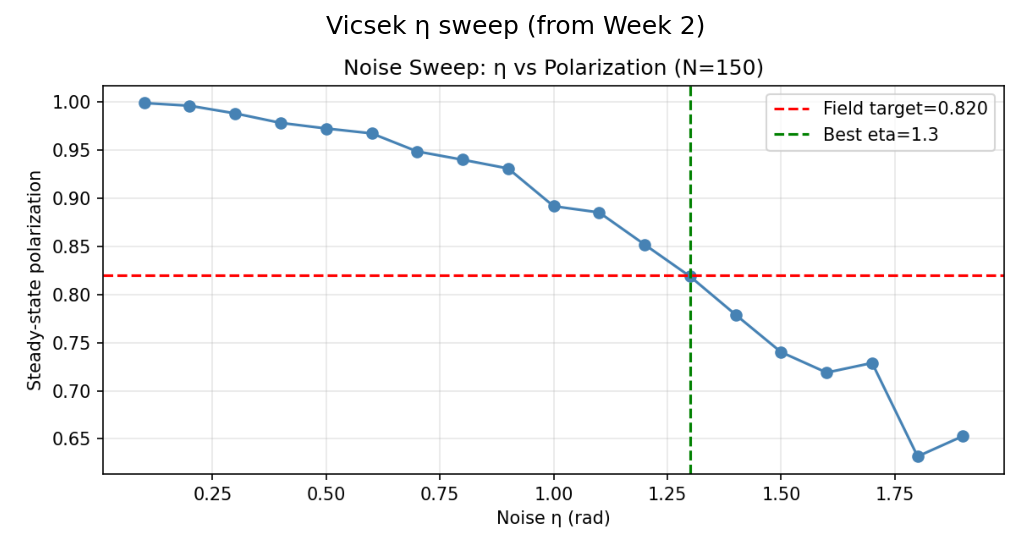

Displayed Vicsek sweep PNG. Overlay Pull sweep here once George provides arrays.


In [13]:
# ── Placeholder: repopulate with actual sweep arrays ─────────────────────────
# Example (replace with actual data):
# eta_sweep    = np.load(WEEK2_ASHER / 'week2' / 'eta_sweep_etas.npy')
# phi_sweep    = np.load(WEEK2_ASHER / 'week2' / 'eta_sweep_phi.npy')
# eta_pull_sweep = np.load(WEEK2_GEORGE / 'week2' / 'pull_eta_sweep_etas.npy')
# phi_pull_sweep = np.load(WEEK2_GEORGE / 'week2' / 'pull_eta_sweep_phi.npy')

print('Noise-sweep figure: load sweep arrays from Week 2 notebooks and plot here.')
print('Vicsek sweep PNG already exists at:', WEEK2 / 'figures' / 'vicsek_noise_sweep.png')

SWEEP_PNG = WEEK2 / 'figures' / 'vicsek_noise_sweep.png'
if SWEEP_PNG.exists():
    from matplotlib.image import imread
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.imshow(imread(str(SWEEP_PNG)))
    ax.axis('off')
    ax.set_title('Vicsek η sweep (from Week 2)', fontsize=12)
    plt.tight_layout()
    plt.show()
    print('Displayed Vicsek sweep PNG. '
          'Overlay Pull sweep here once George provides arrays.')

## 11. Export week3_results.json

In [14]:
week3_results = {
    'vicsek_params':    {k: (None if isinstance(v, float) and np.isnan(v) else v)
                         for k, v in vp.items()},
    'pull_params':      {k: (None if isinstance(v, float) and np.isnan(v) else v)
                         for k, v in pp.items()},
    'field_targets':    ft,
    'vicsek_metrics':   {k: (None if isinstance(v, float) and np.isnan(v) else v)
                         for k, v in vm.items()},
    'pull_metrics':     {k: (None if isinstance(v, float) and np.isnan(v) else v)
                         for k, v in pm.items()},
    'relative_errors': {
        'vicsek': {
            'polarization_mean_pct': rel_err(vm['polarization_mean'], ft['polarization_mean']),
            'turning_angle_std_pct': rel_err(vm['turning_angle_std'], ft['turning_angle_std']),
            'nnd_median_pct':        rel_err(vm['nnd_median'],        ft['nnd_median']),
        },
        'pull': {
            'polarization_mean_pct': rel_err(pm['polarization_mean'], ft['polarization_mean']),
            'turning_angle_std_pct': rel_err(pm['turning_angle_std'], ft['turning_angle_std']),
            'nnd_median_pct':        rel_err(pm['nnd_median'],        ft['nnd_median']),
        }
    },
    'neighbor_map_anisotropy': {
        'field':  'anisotropic — forward void present',
        'vicsek': 'isotropic — no forward void (FAIL)',
        'pull':   'pending George week 2 output'
    }
}

# serialise NaN→None
def _nan_safe(obj):
    if isinstance(obj, dict):
        return {k: _nan_safe(v) for k, v in obj.items()}
    if isinstance(obj, float) and np.isnan(obj): return None
    return obj

W3_JSON = WEEK3 / 'week3_results.json'
with open(W3_JSON, 'w') as f:
    json.dump(_nan_safe(week3_results), f, indent=2)
print(f'Week 3 results exported to {W3_JSON}')

Week 3 results exported to /mnt/work_1/gest9386/CU_Boulder/CSCI-5423/Final_Project/week3/week3_results.json


## 12. Final Sanity Check

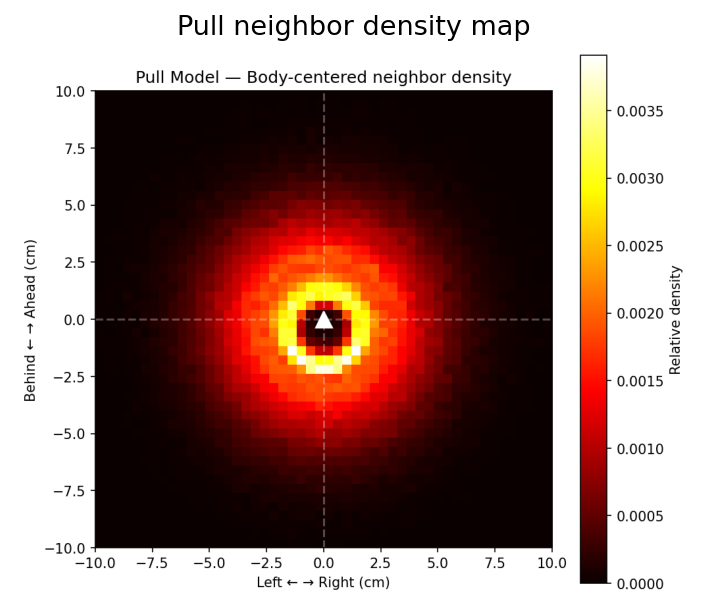

In [15]:
from matplotlib.image import imread
img = imread(str(WEEK2 / 'figures' / 'pull_metric_3.png'))
plt.imshow(img); plt.axis('off'); plt.title('Pull neighbor density map'); plt.show()

---
## Checklist — complete before final submission

- [ ] Paste George's `week2_results.json` path into `PULL_JSON` and re-run cells 1–9
- [ ] Confirm Pull model's `eta_calibrated` key name matches what's in his JSON
- [ ] Load raw density-map arrays and fill in Section 5 / anisotropy index
- [ ] Overlay Pull's eta-sweep on the noise-inflation figure (Section 10)
- [ ] Run Section 8 statistical tests with correct `n_steps` for Pull model
- [ ] Export final `week3_results.json` and commit all figures to `week3/figures/`
- [ ] Write up final report (Section 12 — add below)